# NLP Project — Medical Chatbot
## Step 1: Data Cleaning
**Dataset format:** `data/raw.txt`  
**Output:** `data/cleaned_sequences.txt`

### Cell 1 — Parse raw.txt into structured records

In [3]:
import re
import pandas as pd
import matplotlib.pyplot as plt

def parse_raw_txt(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()

    records_raw = re.split(r'(?=^id=\d+)', content, flags=re.MULTILINE)
    records_raw = [r.strip() for r in records_raw if r.strip()]

    parsed = []
    for block in records_raw:
        record = {}
        lines = block.strip().split('\n')

        record['id'] = lines[0].replace('id=', '').strip()

        record['url'] = ''
        for line in lines:
            if line.startswith('http'):
                record['url'] = line.strip()
                break

        desc_match = re.search(r'Description\s*\n(.+?)(?=Dialogue|$)', block, re.DOTALL)
        record['description'] = desc_match.group(1).strip() if desc_match else ''

        patient_match = re.search(r'Patient:\s*\n(.+?)(?=Doctor:|$)', block, re.DOTALL)
        record['patient'] = patient_match.group(1).strip() if patient_match else ''

        doctor_match = re.search(r'Doctor:\s*\n(.+?)(?=id=|$)', block, re.DOTALL)
        record['doctor'] = doctor_match.group(1).strip() if doctor_match else ''

        if record['patient'] and record['doctor']:
            parsed.append(record)

    return pd.DataFrame(parsed)

df = parse_raw_txt('../data/raw.txt')
print(f"Total records parsed: {len(df)}")
df.head(2)

Total records parsed: 106219


,id,url,description,patient,doctor
0,0,https://www.healthcaremagic.com/questions/How-...,How can one treat intense pain in the stomach ...,"Hi,I m XXXX,I am ulcer patient ,I did my endos...","Hello,I don't think your ulcer is coming back ..."
1,1,https://www.healthcaremagic.com/questions/What...,What causes abdominal pain similar to menstrua...,I took the shot and started duphaston pills fo...,"Hello,Duphaston is a hormonal preparation and ..."


### Cell 2 — All Cleaning Functions

**Order of cleaning:**
1. Remove URLs
2. Remove greetings (opening lines)
3. Remove bullet numbering
4. Remove doctor signature (ending lines) ← NEW
5. Normalize whitespace

In [52]:
import re

# ── FUNCTION 1: Remove URLs ───────────────────────────────────────────────
def remove_urls(text):
    return re.sub(r'http\S+|www\.\S+', '', text)
def normalize_special_chars(text):
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2014', '-').replace('\u2013', '-')
    text = text.replace('\u2026', '...')   # … → ...
    text = text.replace('\u00b4', "'")     # ´ → '
    text = text.replace('\u00bc', '1/4')   # ¼ → 1/4
    text = text.replace('\u00be', '3/4')   # ¾ → 3/4
    text = text.replace('\u00bd', '1/2')   # ½ → 1/2
    text = text.replace('\u200e', '')      # left-to-right mark (invisible)
    text = text.replace('\u200b', '')      # zero-width space (invisible)
    text = text.replace('\u203a', '')      # › single angle quote
    text = text.replace(';', '.')
    text = text.replace('*', '')
    text = text.replace('[', '').replace(']', '')
    text = text.replace('{', '').replace('}', '')
    text = text.replace('@', '')
    text = text.replace('°', '')
    text = text.replace('`', '')
    text = text.replace('$', '')
    text = text.replace('•', '')
    text = text.replace('~', '')
    return text

# ── FUNCTION 2: Remove Greetings ─────────────────────────────────────────
def remove_greetings(text):
    patterns = [
        r'(Hi|Hello|Dear|hey)[\.,!\s]*(dear)?[\.,!\s]*',
        r'Welcome to Healthcaremagic\.com[\.,!\s]*',
        r'(Warm welcome|HiWarm welcome) to Healthcaremagic\.com[\.,!\s]*',
        r'Thanks? for your query[\.,!\s]*',
        r'Thank you for your query[\.,!\s]*',
        r'I (have evaluated|have gone through|understand|studied) your (query|concern)\s*[,\.]?\s*',
        r'I will try to help you as much as I can[\.,!\s]*',
        r'Respected user\s*,?\s*',
        r'(Hi|Hello)[,\s]*Regards\s*!?\s*',
        r"Welcome to ['\"]?Ask A Doctor['\"]? service[\.,!\s]*",
        r'I have reviewed your query[\w\s]*[,\.\s]*',
        r'Welcome to HCM[\.,!\s]*',
        r'Thank you for trusting HCM[\.,!\s]*',
        r'Thanks for (putting your query in|consulting( at my virtual clinic)?) HCM[\.,!\s]*',
        r'Thanks for consulting (on|at) HCM[\.,!\s]*',
        r'(on|to)\s+HCM["\'\.,!\s]*',
        r'and faith in HCM[\.,!\s]*',
        r'Dr\.\s+\w+\s+warmly welcomes you[\.,!\s]*',
        r'Thank you (for )?asking HCM[\.,!\s]*',
        r'I have carefully (worked through|reviewed|gone through) your case[^.]*\.',
        r'Being your (physician|doctor),?\s*I want to assure[^.]*\.',
        r'to [Mm]y HCM [Cc]linic[^.]*\.',
        r'Thank you for your question on HCM[\.,!\s]*',
        r'Thanks for (writing|sharing[^!]*?)( (to|with|in))? HCM[\.,!\s]*',
        r'and thank you for asking us on HCM[\.,!\s]*',
        r'and welcome to hcm\s*',
        r'there[\.,]?\s*(Thanks for using HCM|in HCM)[\.,!\s]*',
        r'^there[\.,\s]+',
        r'I am Dr\.?\s*\w+,?\s*and I am pleased to (help you|answer your query)[\.,!\s]*',
        r'Good (Evening|Morning|Afternoon|Night)[,!\s]+',
        r'Thank(?:\s+you)? for (using|contacting|choosing) HCM[\.,!\s]*',
        r'welcome to the HCM[\.,!\s]*',
        r'greetings from HCM[\.,\.\s]*',
        r'^(sir|madam|friend)[,!\.\s]+',
        r'^\w+\.\s+in HCM[\.,!\s]*',
        r'greeting\s+s from HCM[\.,\.\s]*',
        r'Thanks for asking HCM[\.,!\s]*',
        r'thanks for posting your concern in (the )?HCM[\.,!\s]*',
    ]
    for pattern in patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    return text.strip()


# ── FUNCTION 3: Remove Structural Labels ─────────────────────────────────
def remove_structural_labels(text):
    patterns = [
        r'^Brief\s+answer[\s\.\-:]*',
        r'^Detailed?\s+answer[\s\.\-:]*',
        r'^Brei?f[\s\.]+[Nn]eed some detail[\s\.]*',
    ]
    for pattern in patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE | re.MULTILINE)
    return text.strip()


# ── FUNCTION 4: Remove Bullet Numbering ──────────────────────────────────
def remove_bullet_numbering(text):
    text = re.sub(r'^[\*\•\-\>]+\s+', '', text, flags=re.MULTILINE)
    text = re.sub(r'^\d+[\.\.\)]\s+', '', text, flags=re.MULTILINE)
    return text


# ── FUNCTION 5: Remove Doctor Signature ──────────────────────────────────
def remove_doctor_signature(text):

    end_patterns = [
        r'Hope I have answered your query.*$',
        r'I hope I have answered you[r]? query.*$',
        r'Hope this answers your question.*$',
        r'I hope this information.*$',
        r'I hope t(his|s) information.*$',
        r'Hope t(his|s) (information|clears|will help|info helps|answers|is helpful).*$',
        r'Hope t(his|s) clears your (query|doubt|doubts).*$',
        r'Hope t(his|s) will help you.*$',
        r'Hope t(his|s) info helps.*$',
        r'Hope t(his|s) answers your query.*$',
        r'Hope (that helps|this clears|this helps|this will help).*$',
        r'Hope to clarify.*$',
        r'Hope your concern has been resolved.*$',
        r'Hope the answer is helpful.*$',
        r'I hope I have solved your query.*$',
        r'I hope ts answers your query.*$',
        r'Hope ts is helpful.*$',
        r'Hope it helps.*$',
        r'I hope ts helps.*$',
        r'I hops? ts helps.*$',
        r'Hope above suggestions will be helpful.*$',
        r'Hope ts would (resolve|help|answer|clarify).*$',
        r'Hope to have been helpful.*$',
        r'hcm\s*$',
        r'Feel free to (ask|post) (any )?(doubts|questions|further|queries).*$',
        r'Always feel free to ask any further doubts.*$',
        r'Welcome for (any further|further) (doubts|assistance|guidance|questions|quer).*$',
        r'Welcome for further.*$',
        r'Wellcome? (to HCM )?for further quer.*$',
        r'Further quer(ies|rries) will be appreciated.*$',
        r'If you have additional questions.*$',
        r'Please do not hesitate.*$',
        r'Should you (have any further|need any further).*$',
        r'Do write back to me.*$',
        r'Let me know if (I can assist|you need).*$',
        r'Get Well Soon.*$',
        r'Best Wishes.*$',
        r'Wishing you (good health|fine recovery|a speedy recovery).*$',
        r'Wisng (you|her|him|early) (fine recovery|a speedy recovery|good health|recovery).*$',
        r'Wish you (good health|a speedy recovery|an early recovery|the best).*$',
        r'Wish you and.*$',
        r'Wish your.*$',
        r'I wish you an early recovery.*$',
        r'Thank you &.*$',
        r'Take care\.?$',
        r'Ok and\s*$',
        r'Takecare.*$',
        r'Stay healthy.*$',
        r'(Take care[\s,]*)?Dr\.?\s+[A-Z][\w\s\.,]*?(General Surgeon|General & Family Physician|Family Physician|Pulmonologist|Physician|Neurologist|Surgeon|Cardiologist|Dermatologist|Pediatrician|Gynecologist|Urologist|Gastroenterologist|Psychiatrist|Orthopedic|Radiologist|ENT|Physiotherapist|Psychologist|Oncologist|Ophthalmologist|Dentist).*$',
        r'[-–]\s*Dr\.?\s*[A-Z][\w\s\.,]{2,30}\s*$',
        r'Dr\.?\s*[A-Z][\w\s\.,]{2,20}\s*$',
        r'Dr\.?\s*\w+\d*\s*$',
        r'Please don\'t forget to add your.*?(feedback|review).*$',
        r'Have a (wonderful|blessed|great|good|nice) (time|day|health|life).*$',
        r'Keep in touch (for a follow[\-\s]?up|for further).*$',
        r'I am available 24.?7.*$',
        r'(Please )?[Dd]on\'?t forget to (add|give|leave|provide) (your )?(precious |positive )?feedback.*$',
        r'[Ww]ith (any further query in ts )?[Ww]rite review\s*ASAP.*$',
        r'[Ww]ith strong recommendations for (Me and )?HCM.*$',
        r'Good (night|evening|morning|day) from \w+[\.\-\s]*$',
        r'[Gg]reetings[\.,!]*\s*$',
        r'[Hh]ave a nice day.*$',
        r'I (will|shall) be (glad|happy) to (answer|help).*$',
        r'(please )?do (post|leave|give|add) your (precious |positive )?feedback.*$',
        r"[Dd]on'?t hesitate to write to us.*$",
        r'If you are satisfied with my answer.*$',
        r'[Tt]hanks for using HCM.*$',
        r'[Gg]ood [Ll]uck[\.,!]*\s*$',
        r'[Dd]o contact us for more quer.*$',
        r'[Tt]hank you (and )?do contact us.*$',
        r'[Tt]hank you from HCM[\.,!\s]*$',
        r'[Tt]hanks for using HMC[\.,!\s]*$',
        r'[Yy]ou can ask further from HCM.*$',
        r'[Ss]ee a doctor with reports or post in HCM.*$',
        r'[Yy]ou may write (to )?HCM.*$',
        r'[Gg]ood [Dd]ay[\.,!]*\s*$',
        r'[Ff]or any further information,?\s*please write back.*$',
    ]

    phrase_patterns = [
        r'Thanks for (choosing|using) [Hh]ealth\s?[Cc]are\s?[Mm]agic\.?com\s*',
        r'Thanks for using Healthcaremagic\.com\s*',
        r'Healthcaremagic\.com\s*',
        r'Health\s?Care\s?Magic\s*',
        r"['\"]?Ask A Doctor['\"]?\s*(service)?\s*",
        r'at HCM\b\s*',
        r'^Dr\.?\s+[A-Z][a-zA-Z]+\s+answering your question[\.\s]*',
        r'(Kind )?[Rr]egards?[\s,!\.]*',
        r'rgds[\s,]*dr?\s*\w+',
        r'[\w\.-]+@[\w\.-]+\.\w+',
        r'(\+\d{1,3}[-\s]?)?\d{10,}',
        r'Mob(ile)?\s*(no|number)?\s*[-:]?\s*[\d\s\+\-]+',
        r'at my virtual clinic HCM\s*',
        r'Thanks for consulting (at my virtual clinic\s+)?HCM[\.,!\s]*',
        r'(?<!\w)[a-z]:\s*(?=[A-Z])',
        r'\bHCM(?=[A-Za-z])',
    ]

    for pattern in end_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE | re.MULTILINE)

    for pattern in phrase_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)

    return text.strip()





# ── FUNCTION 7: Normalize Whitespace ─────────────────────────────────────
def normalize_whitespace(text):
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\s+[A-Za-z]\s*$', '', text)
    return text.strip()


# ── MASTER FUNCTION ───────────────────────────────────────────────────────
def clean_text(text):
    if pd.isna(text): return ''
    text = remove_urls(text)
    text = remove_greetings(text)
    text = remove_structural_labels(text)
    text = remove_bullet_numbering(text)
    text = remove_doctor_signature(text)
    text = normalize_special_chars(text)   # ← this was missing
    text = normalize_whitespace(text)
    return text

print("All cleaning functions ready ✓")

All cleaning functions ready ✓


### Cell 3 — Apply Cleaning & Verify Result

In [ ]:
df['patient_clean'] = df['patient'].apply(clean_text)
df['doctor_clean']  = df['doctor'].apply(clean_text)

=== BEFORE CLEANING (last 300 chars) ===
ering your question.By description it looks like pancreas pain. Pancreas is a gland in the body that produces enzymes for the digestion of certain foods. Alcohol makes it worse. I suggest to follow up with your Gastroenterologist to find out the cause as he will probably do tests and a scan. Regards

=== AFTER CLEANING (last 300 chars) ===



### Cell 4 — Word Count Distribution Plot

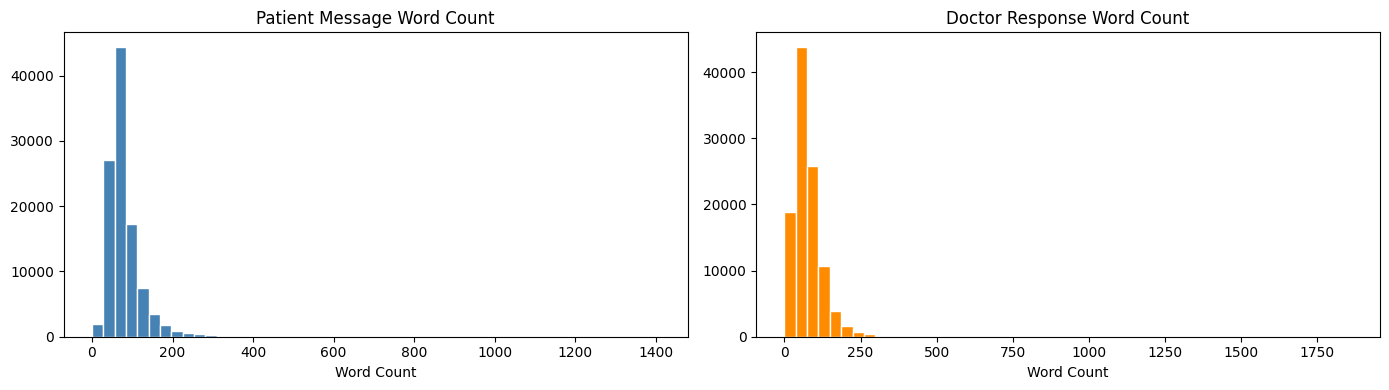

          patient_wc      doctor_wc
count  106219.000000  106219.000000
mean       81.702727      76.010309
std        49.478378      49.958628
min         0.000000       0.000000
25%        56.000000      44.000000
50%        68.000000      66.000000
75%        92.000000      95.000000
max      1408.000000    1863.000000


In [54]:
df['patient_wc'] = df['patient_clean'].apply(lambda x: len(x.split()))
df['doctor_wc']  = df['doctor_clean'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['patient_wc'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Patient Message Word Count')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel
('Frequency')

axes[1].hist(df['doctor_wc'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Doctor Response Word Count')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('../data/word_count_distribution.png', dpi=150)
plt.show()

print(df[['patient_wc', 'doctor_wc']].describe())

### 


Cell 5 — Filter by Length

In [ ]:

df['combined_input'] = df.apply(
    lambda row: clean_text(row['description']) + " " + row['patient_clean'],
    axis=1
)

# Word counts on actual inputs we will use
df['combined_wc'] = df['combined_input'].apply(lambda x: len(x.split()))
df['doctor_wc']   = df['doctor_clean'].apply(lambda x: len(x.split()))

# Filter based on combined input
MIN_COMBINED_WORDS = 15    # description + patient together
MAX_COMBINED_WORDS = 220   
MIN_DOCTOR_WORDS   = 15
MAX_DOCTOR_WORDS   = 300

df_filtered = df[
    (df['combined_wc'] >= MIN_COMBINED_WORDS) &
    (df['combined_wc'] <= MAX_COMBINED_WORDS) &
    (df['doctor_wc']   >= MIN_DOCTOR_WORDS)   &
    (df['doctor_wc']   <= MAX_DOCTOR_WORDS)
].reset_index(drop=True)

print(f"Records before filtering : {len(df):,}")
print(f"Records after filtering  : {len(df_filtered):,}")
print(f"Records removed          : {len(df) - len(df_filtered):,}")

Records before filtering : 106,219
Records after filtering  : 101,299
Records removed          : 4,920


### Cell 6 — Convert to Training Sequences
Format: `<patient> symptom text <doctor> response text <eos>`

In [56]:
def make_sequence(combined_input, doctor_text):
    return f"<patient> {combined_input} <doctor> {doctor_text} <eos>"

df_filtered['sequence'] = df_filtered.apply(
    lambda row: make_sequence(row['combined_input'], row['doctor_clean']),
    axis=1
)

print("Sample sequence:")
print(df_filtered['sequence'][0])
print("\nTotal sequences:", len(df_filtered))

Sample sequence:
<patient> How can one treat intense pain in the stomach wle suffering from ulcer? I m XXXX,I am ulcer patient ,I did my endoscopy last yr in July and took medication till Feb after that I left the medicine and started taking DGL and probiotic for a month after that I did endoscopy again and found out that only superficial scars are left ..but after endoscopy I really felt great pain the stomach again and mild pain after few days.my doc told me not to take gh protein diets.but I ignored and took it and now I sometimes feel Pricky feeling in my stomach .I m worried whether my ulcer is coming back <doctor> I don't tnk your ulcer is coming back but you should be absolutely careful with the diet as your doctor has advised you. If it will be very intense than contact your doctor and he or she will advise you further about it. <eos>

Total sequences: 101299


### Cell 7 — Save Outputs

In [57]:
# One sequence per line — used for tokenizer training in Step 2
with open('../data/cleaned_sequences.txt', 'w', encoding='utf-8') as f:
    for seq in df_filtered['sequence']:
        f.write(seq + '\n')

# CSV for manual inspection
df_filtered[['id', 'patient_clean', 'doctor_clean', 'patient_wc', 'doctor_wc']].to_csv(
    '../data/cleaned_data.csv', index=False
)

print("Saved:")
print("  data/cleaned_sequences.txt  ← used in Step 2 tokenizer")
print("  data/cleaned_data.csv       ← open this to verify cleaning")

Saved:
  data/cleaned_sequences.txt  ← used in Step 2 tokenizer
  data/cleaned_data.csv       ← open this to verify cleaning


### Cell 8 — Final Stats

In [58]:
total_words = df_filtered['sequence'].apply(lambda x: len(x.split())).sum()
avg_seq_len = df_filtered['sequence'].apply(lambda x: len(x.split())).mean()
max_seq_len = df_filtered['sequence'].apply(lambda x: len(x.split())).max()

print("=== Final Dataset Stats ===")
print(f"Total sequences   : {len(df_filtered):,}")
print(f"Total words       : {total_words:,}")
print(f"Avg sequence len  : {avg_seq_len:.1f} words")
print(f"Max sequence len  : {max_seq_len} words")

=== Final Dataset Stats ===
Total sequences   : 101,299
Total words       : 16,743,042
Avg sequence len  : 165.3 words
Max sequence len  : 504 words


In [59]:
from sklearn.model_selection import train_test_split

# First split — separate test from the rest
train_val, test = train_test_split(
    df_filtered['sequence'], 
    test_size=0.10, 
    random_state=42
)

# Second split — separate validation from train
train, val = train_test_split(
    train_val, 
    test_size=0.111,  # 0.111 of 90% = 10% of total
    random_state=42
)

print(f"Train      : {len(train):,}")
print(f"Validation : {len(val):,}")
print(f"Test       : {len(test):,}")

# Save all three splits
def save_split(data, filename):
    with open(filename, 'w', encoding='utf-8') as f:
        for seq in data:
            f.write(seq + '\n')

save_split(train, '../data/train.txt')
save_split(val,   '../data/val.txt')
save_split(test,  '../data/test.txt')

print("\nSaved:")
print("  data/train.txt")
print("  data/val.txt")
print("  data/test.txt")




Train      : 81,049
Validation : 10,120
Test       : 10,130

Saved:
  data/train.txt
  data/val.txt
  data/test.txt
